# Communities and Crime — klasterovanje

U ovoj svesci se primenjuje **6 algoritama klasterovanja** na više skupova karakteristika:

| # | Algoritam |
|---|-----------|
| 1 | k-sredina |
| 2 | Aglomerativno (sakupljajuće) hijerarhijsko klasterovanje|
| 3 | DBSCAN |
| 4 | CLARANS |
| 5 | BIRCH |
| 6 | CURE |

**Korišćeni skupovi karakteristika:**
- `Full` — sve preprocesirane karakteristike
- `PCA-70` — PCA komponente koje objašnjavaju 70% varijanse
- `PCA-80` — PCA komponente koje objašnjavaju 80% varijanse
- `Economic` — odabrane socioekonomske karakteristike

> **Napomena:** prvo pokrenuti svesku **`01_preprocessing_eda.ipynb`** kako bi se generisali neophodni .csv fajlovi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, Birch
)
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import warnings
warnings.filterwarnings('ignore')

import pyclustering.core.wrapper as _wr
_wr.ccore_library.workable = lambda: False
from pyclustering.cluster.clarans import clarans as CLARANS_algo
from pyclustering.cluster.cure import cure as CURE_algo

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Učitavanje podataka

In [2]:
X_full  = pd.read_csv('../data/data_preprocessed.csv')
X_pca70 = pd.read_csv('../data/data_pca_70.csv')
X_pca80 = pd.read_csv('../data/data_pca_80.csv')
X_econ  = pd.read_csv('../data/data_economic.csv')

print(f'Full features:      {X_full.shape}')
print(f'PCA-70 components:  {X_pca70.shape}')
print(f'PCA-80 components:  {X_pca80.shape}')
print(f'Economic subset:    {X_econ.shape}')

feature_sets = {
    'Full':     X_full.values,
    'PCA-70':   X_pca70.values,
    'PCA-80':   X_pca80.values,
    'Economic': X_econ.values
}

pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_full)
print('\n2D PCA projection ready for visualization.')

Full features:      (2215, 102)
PCA-70 components:  (2215, 7)
PCA-80 components:  (2215, 12)
Economic subset:    (2215, 20)

2D PCA projection ready for visualization.


## 2. Pomoćne funkcije

In [3]:
def compute_metrics(X, labels):
    """Compute silhouette, Davies-Bouldin, and Calinski-Harabasz scores.
    Noise points (label == -1) are excluded from computation.
    """
    arr = X if isinstance(X, np.ndarray) else X.values
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    if n_clusters < 2:
        return {
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': np.nan, 'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }

    mask = labels != -1
    X_c, L_c = arr[mask], labels[mask]

    if len(set(L_c)) < 2:
        return {
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': np.nan, 'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }

    sample = min(2000, len(X_c))
    return {
        'n_clusters':        n_clusters,
        'n_noise':           n_noise,
        'silhouette':        silhouette_score(X_c, L_c, sample_size=sample, random_state=42),
        'davies_bouldin':    davies_bouldin_score(X_c, L_c),
        'calinski_harabasz': calinski_harabasz_score(X_c, L_c)
    }


def plot_clusters(X_viz, labels, title, ax=None):
    """Scatter plot of clusters projected onto 2D PCA space."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    unique = sorted(set(labels))
    palette = sns.color_palette('tab10', n_colors=max(len(unique), 1))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % len(palette)]
        name  = 'Noise' if lbl == -1 else f'C{lbl}'
        ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
                   c=[color], label=name, alpha=0.5, s=14)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.set_title(title, fontsize=10)
    if len(unique) <= 12:
        ax.legend(markerscale=1.8, fontsize=7, loc='best')
    return ax


def pyclustering_to_labels(clusters, n_samples):
    """Convert pyclustering output (list of index lists) to a numpy labels array."""
    labels = np.full(n_samples, -1, dtype=int)
    for cluster_id, indices in enumerate(clusters):
        for idx in indices:
            labels[idx] = cluster_id
    return labels


all_results = {}
print('Helper functions ready.')

Helper functions ready.


---
## Algoritam 1 — k-sredina

Algoritam k-sredina deli podatke u *k* klastera minimizacijom sume kvadrata rastojanja unutar klastera.  
Koristimo **metod lakta** i **siluetа koeficijent** za izbor optimalnog *k*.

K-Means k selection on full feature set...
   k      Inertia   Silhouette
   2       189316       0.1652
   3       169221       0.1777
   4       157690       0.1255
   5       147147       0.1255
   6       137568       0.1402
   7       130950       0.1411
   8       124601       0.1282
   9       120380       0.1227
  10       117082       0.1092


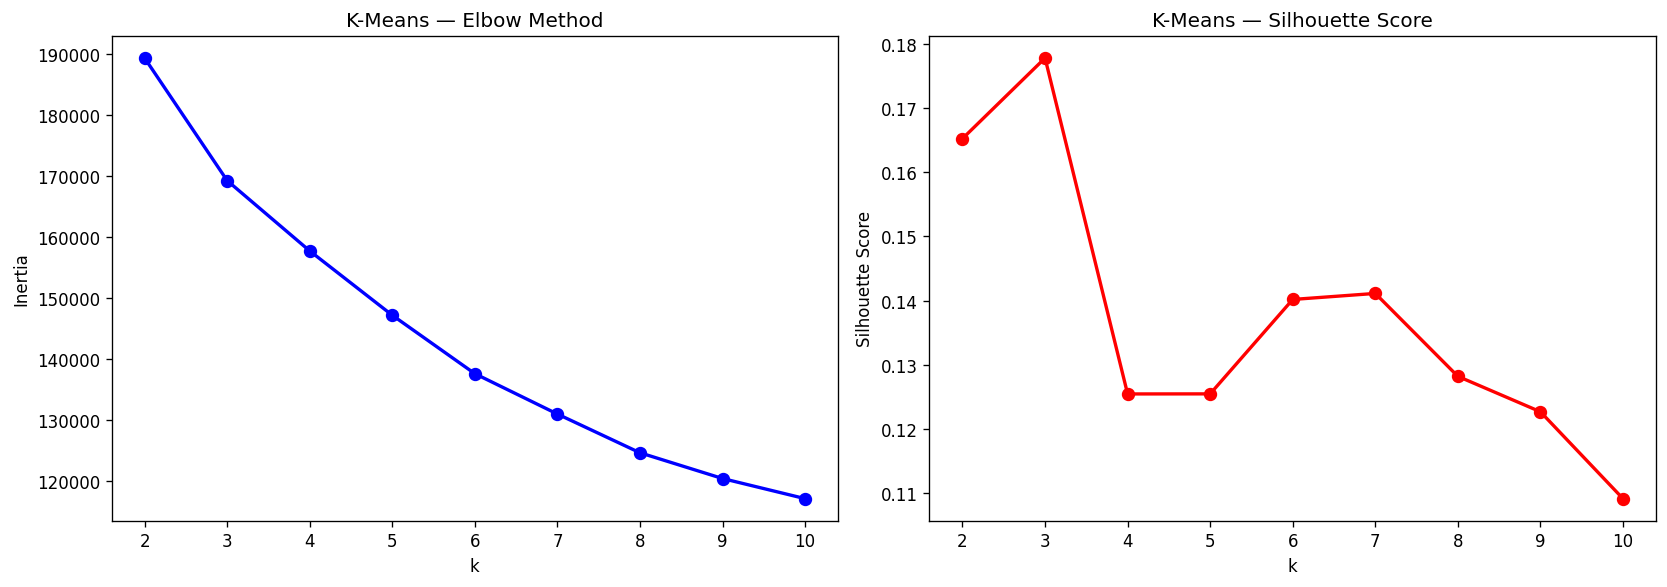


Best k by silhouette: 3


In [4]:
k_range = range(2, 11)
inertias, silhouettes = [], []

print('K-Means k selection on full feature set...')
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>12}')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full.values)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_full.values, labels, sample_size=min(2000, len(X_full)), random_state=42)
    silhouettes.append(sil)
    print(f'{k:>4} {km.inertia_:>12.0f} {sil:>12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means — Elbow Method')

axes[1].plot(list(k_range), silhouettes, 'ro-', linewidth=2, markersize=7)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means — Silhouette Score')

plt.tight_layout()
plt.savefig('../figures/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f'\nBest k by silhouette: {best_k}')

Running K-Means (k=3) on all feature sets...
  Full         sil=0.1777  DB=1.7846  CH=370.6
  PCA-70       sil=0.2686  DB=1.3279  CH=606.3
  PCA-80       sil=0.2277  DB=1.5045  CH=502.4
  Economic     sil=0.2065  DB=1.6030  CH=720.4


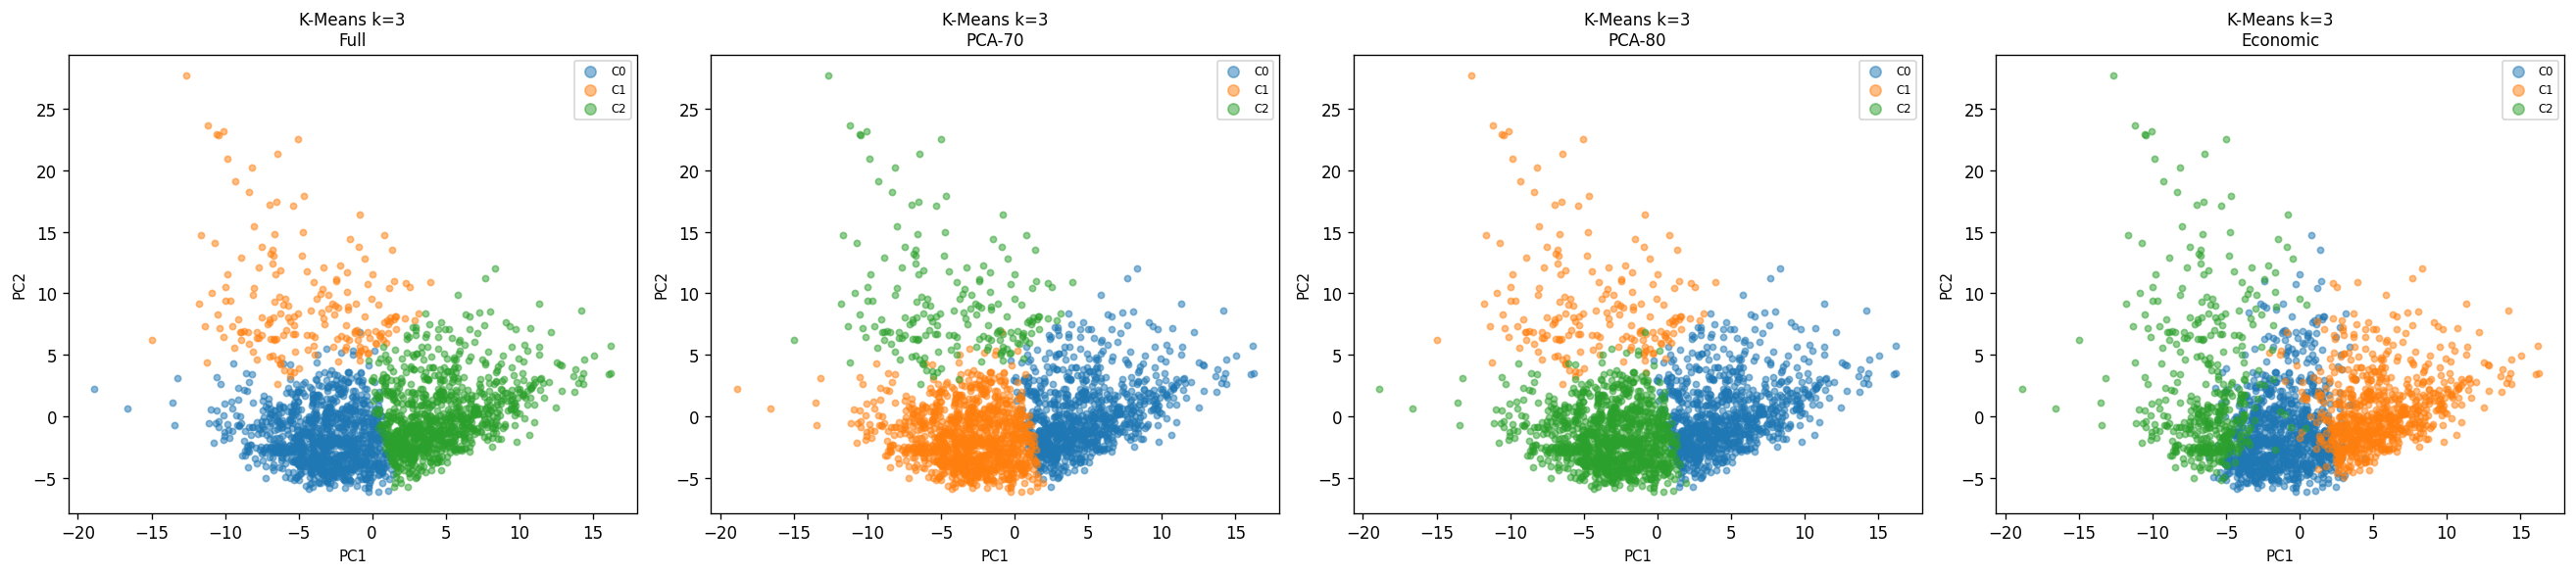

K-Means saved.


In [5]:
print(f'Running K-Means (k={best_k}) on all feature sets...')
kmeans_results = {}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (name, X) in enumerate(feature_sets.items()):
    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    m = compute_metrics(X, labels)
    kmeans_results[name] = {'labels': labels, 'metrics': m, 'model': km}
    plot_clusters(X_viz, labels, f'K-Means k={best_k}\n{name}', axes[i])
    print(f'  {name:<12} sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  CH={m["calinski_harabasz"]:.1f}')

plt.tight_layout()
plt.savefig('../figures/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['KMeans'] = kmeans_results
joblib.dump(kmeans_results, '../results/results_kmeans.pkl')
print('K-Means saved.')

---
## Algoritam 2 — aglomerativno (sakupljajuće) hijerarhijsko klasterovanje

Gradi hijerarhiju klastera odozdo naviše. Vizuelizujemo **dendrogram** i poredimo tri strategije: `Ward-ov metod`, `potpuna veza`, `grupno-prosečna veza`.

Computing dendrogram (Ward linkage, first 500 samples on PCA-70)...


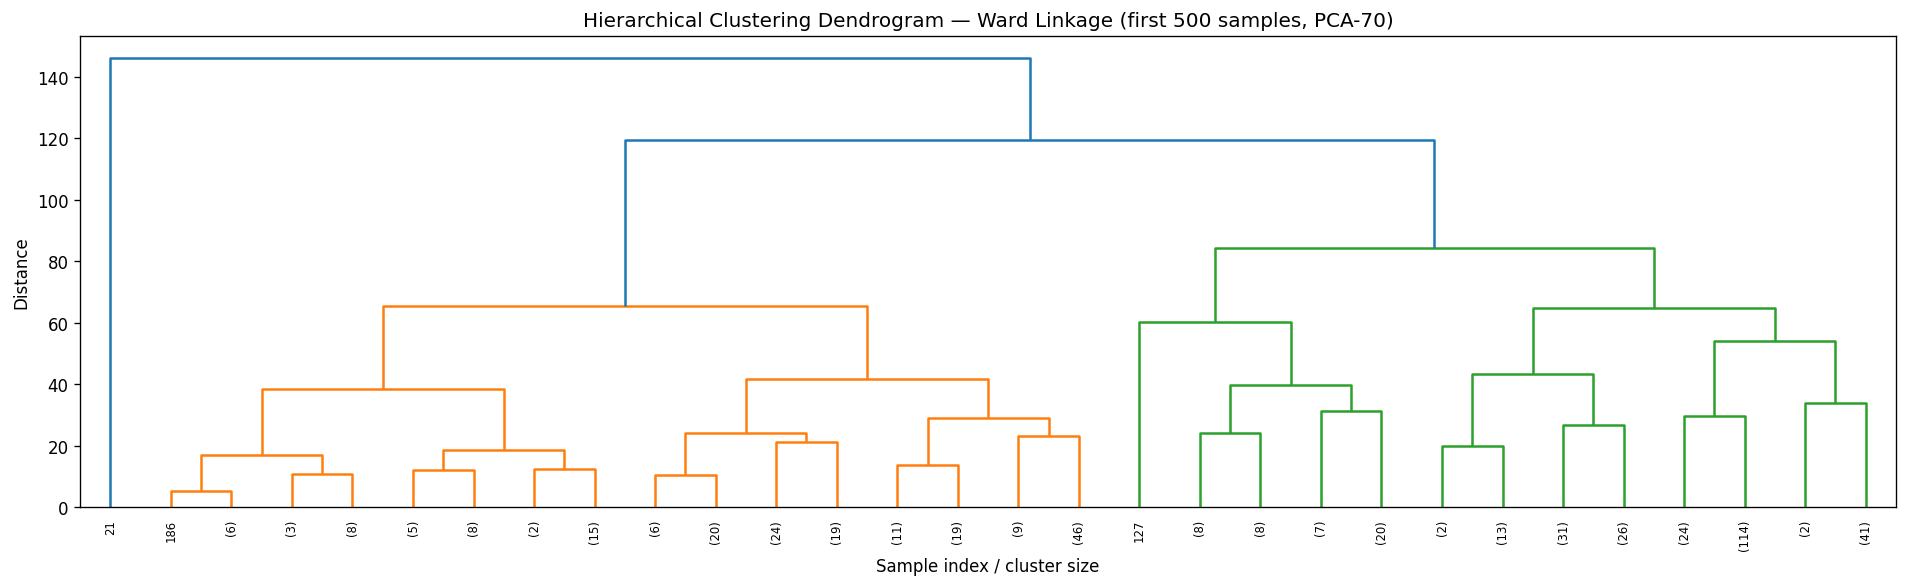

Dendrogram saved.


In [6]:
print('Computing dendrogram (Ward linkage, first 500 samples on PCA-70)...')
Z = linkage(X_pca70.values[:500], method='ward')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=7, color_threshold=None)
ax.set_title('Hierarchical Clustering Dendrogram — Ward Linkage (first 500 samples, PCA-70)')
ax.set_xlabel('Sample index / cluster size')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrogram saved.')

  Agglomerative (ward, Full)... sil=0.1604
  Agglomerative (ward, PCA-70)... sil=0.2325
  Agglomerative (ward, PCA-80)... sil=0.1927
  Agglomerative (ward, Economic)... sil=0.2118
  Agglomerative (complete, Full)... sil=0.7278
  Agglomerative (complete, PCA-70)... sil=0.7693
  Agglomerative (complete, PCA-80)... sil=0.7504
  Agglomerative (complete, Economic)... sil=0.4685
  Agglomerative (average, Full)... sil=0.6112
  Agglomerative (average, PCA-70)... sil=0.7693
  Agglomerative (average, PCA-80)... sil=0.7504
  Agglomerative (average, Economic)... sil=0.6796


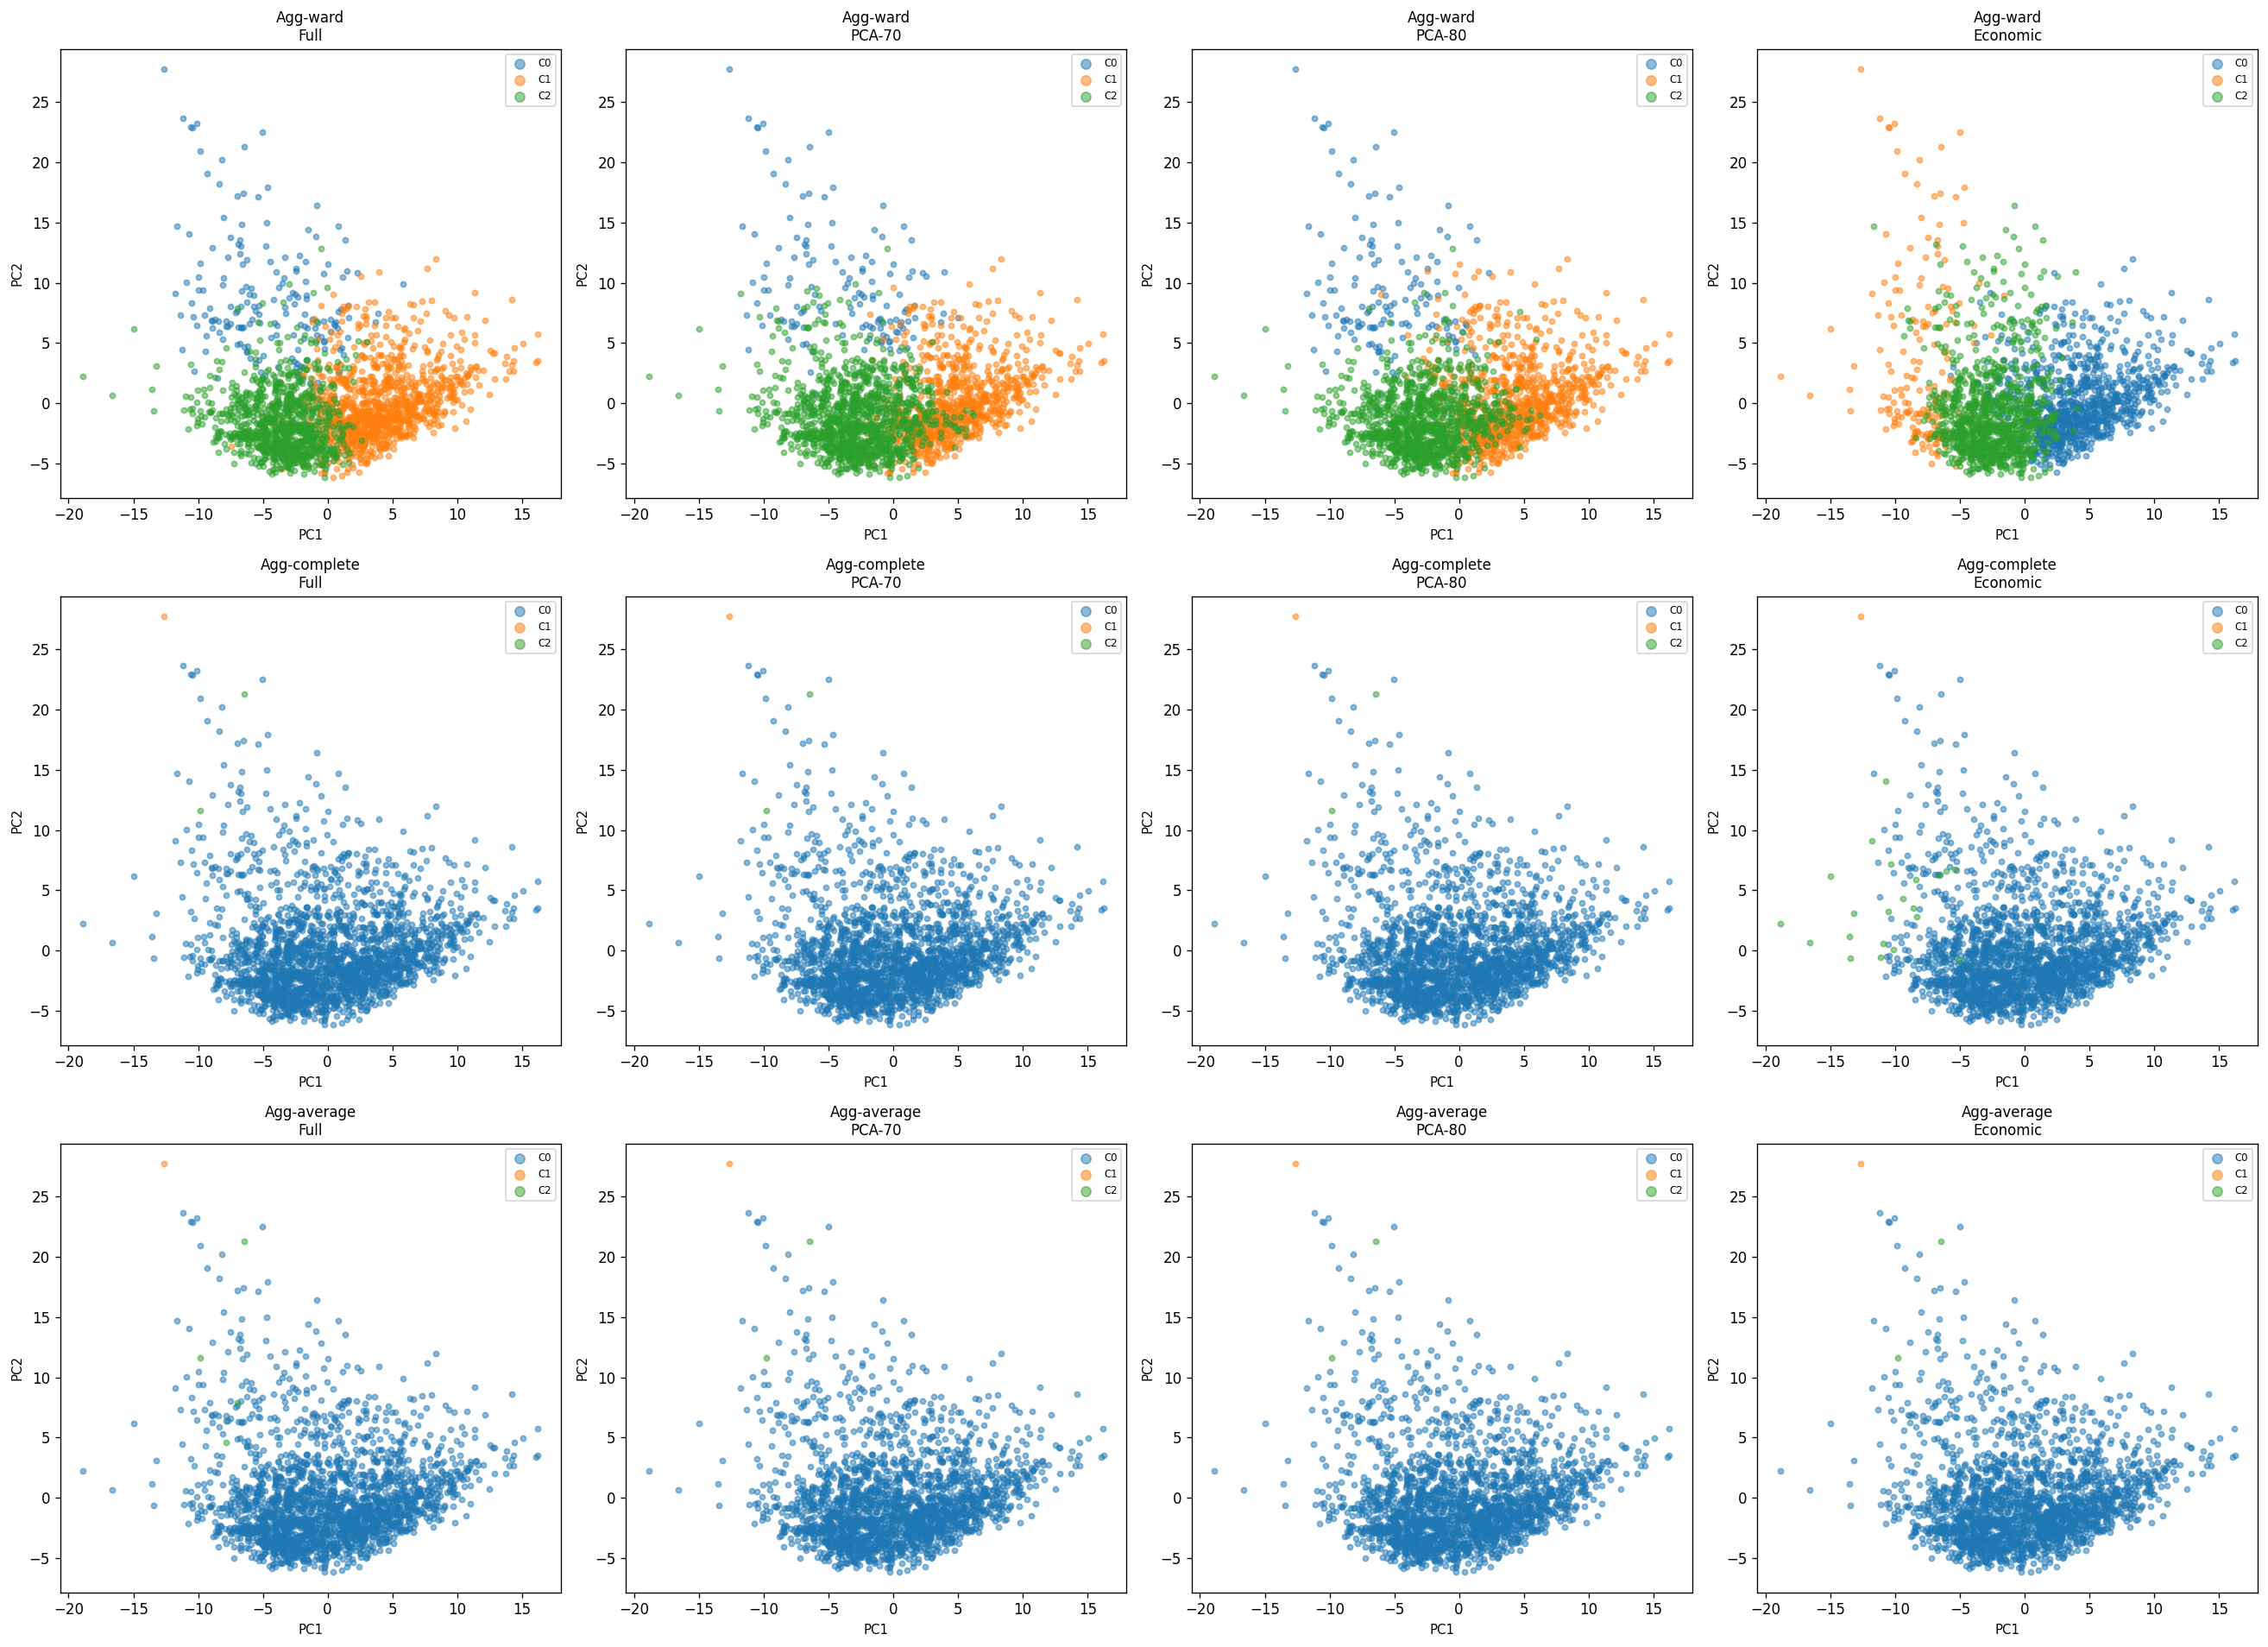

Agglomerative results saved.


In [7]:
linkage_methods = ['ward', 'complete', 'average']
agg_results = {}

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
for row, lm in enumerate(linkage_methods):
    for col, (name, X) in enumerate(feature_sets.items()):
        print(f'  Agglomerative ({lm}, {name})...', end=' ')
        agg = AgglomerativeClustering(n_clusters=best_k, linkage=lm)
        labels = agg.fit_predict(X)
        m = compute_metrics(X, labels)
        key = f'{lm}_{name}'
        agg_results[key] = {'labels': labels, 'metrics': m}
        plot_clusters(X_viz, labels, f'Agg-{lm}\n{name}', axes[row, col])
        print(f'sil={m["silhouette"]:.4f}')

plt.tight_layout()
plt.savefig('../figures/agglomerative_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['Agglomerative'] = agg_results
joblib.dump(agg_results, '../results/results_agglomerative.pkl')
print('Agglomerative results saved.')

---
## Algoritam 3 — DBSCAN

Algoritam klasterovanja zasnovan na gustini.  
Ključni parametri: `eps` (poluprečnik okoline) i `min_samples` (minimalan broj suseda).  
Vrednost `eps` procenjujemo pomoću **k-distance grafa** (sortirana rastojanja do k-tog najbližeg suseda).

Computing 5-NN distance graph on PCA-70...


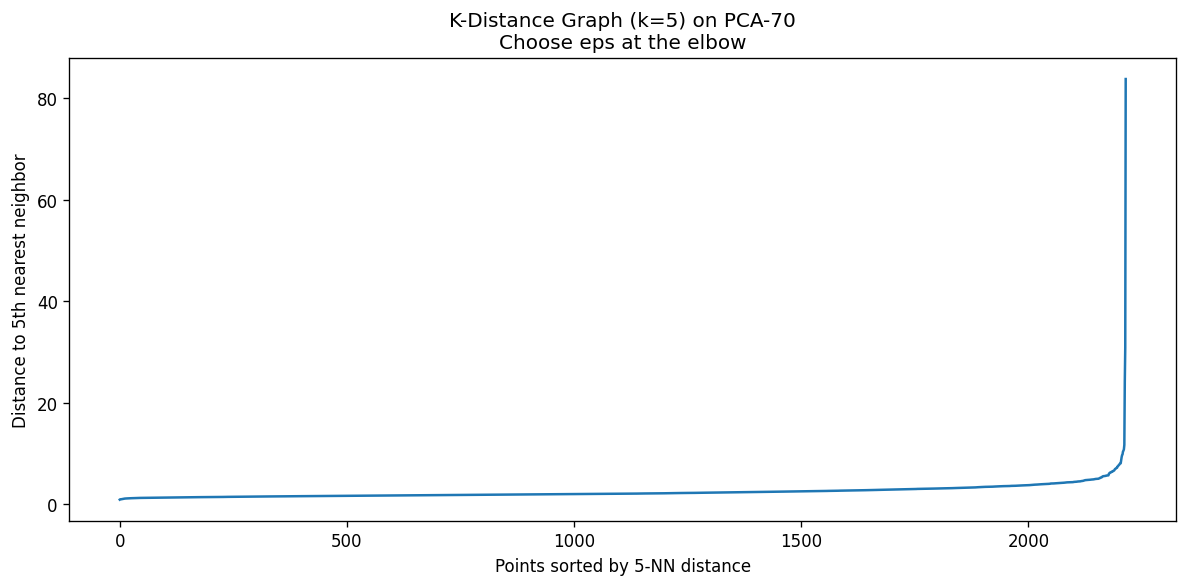

In [8]:
print('Computing 5-NN distance graph on PCA-70...')
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca70.values)
distances, _ = nbrs.kneighbors(X_pca70.values)
dist_sorted = np.sort(distances[:, 4])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dist_sorted)
ax.set_xlabel('Points sorted by 5-NN distance')
ax.set_ylabel('Distance to 5th nearest neighbor')
ax.set_title('K-Distance Graph (k=5) on PCA-70\nChoose eps at the elbow')
plt.tight_layout()
plt.savefig('../figures/dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
dbscan_configs = [
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 5},
    {'eps': 4.0, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 10},
    {'eps': 5.0, 'min_samples': 5},
    {'eps': 5.0, 'min_samples': 10},
]

dbscan_results = {}
best_sil, best_cfg = -1, dbscan_configs[1]

print(f'{"eps":>6} {"min_s":>6} {"clusters":>10} {"noise":>8} {"silhouette":>12}')
for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    labels = db.fit_predict(X_pca70.values)
    m = compute_metrics(X_pca70.values, labels)
    key = f'eps{cfg["eps"]}_ms{cfg["min_samples"]}'
    dbscan_results[key] = {'labels': labels, 'metrics': m, 'config': cfg}
    sil = m['silhouette'] if not np.isnan(m['silhouette']) else -1
    if sil > best_sil and m['n_clusters'] >= 2:
        best_sil, best_cfg = sil, cfg
    print(f'{cfg["eps"]:>6} {cfg["min_samples"]:>6} {m["n_clusters"]:>10} {m["n_noise"]:>8} {sil:>12.4f}')

print(f'\nBest config: eps={best_cfg["eps"]}, min_samples={best_cfg["min_samples"]}')

   eps  min_s   clusters    noise   silhouette
   2.0      5          9      933      -0.1939
   3.0      5          5      296       0.0938
   4.0      5          3       95       0.5612
   3.0     10          2      455       0.4696
   5.0      5          1       36      -1.0000
   5.0     10          2       52       0.5443

Best config: eps=4.0, min_samples=5


  PCA-70     clusters=3, noise=95, sil=0.5612
  PCA-80     clusters=7, noise=315, sil=0.0393
  Economic   clusters=1, noise=13, sil=nan


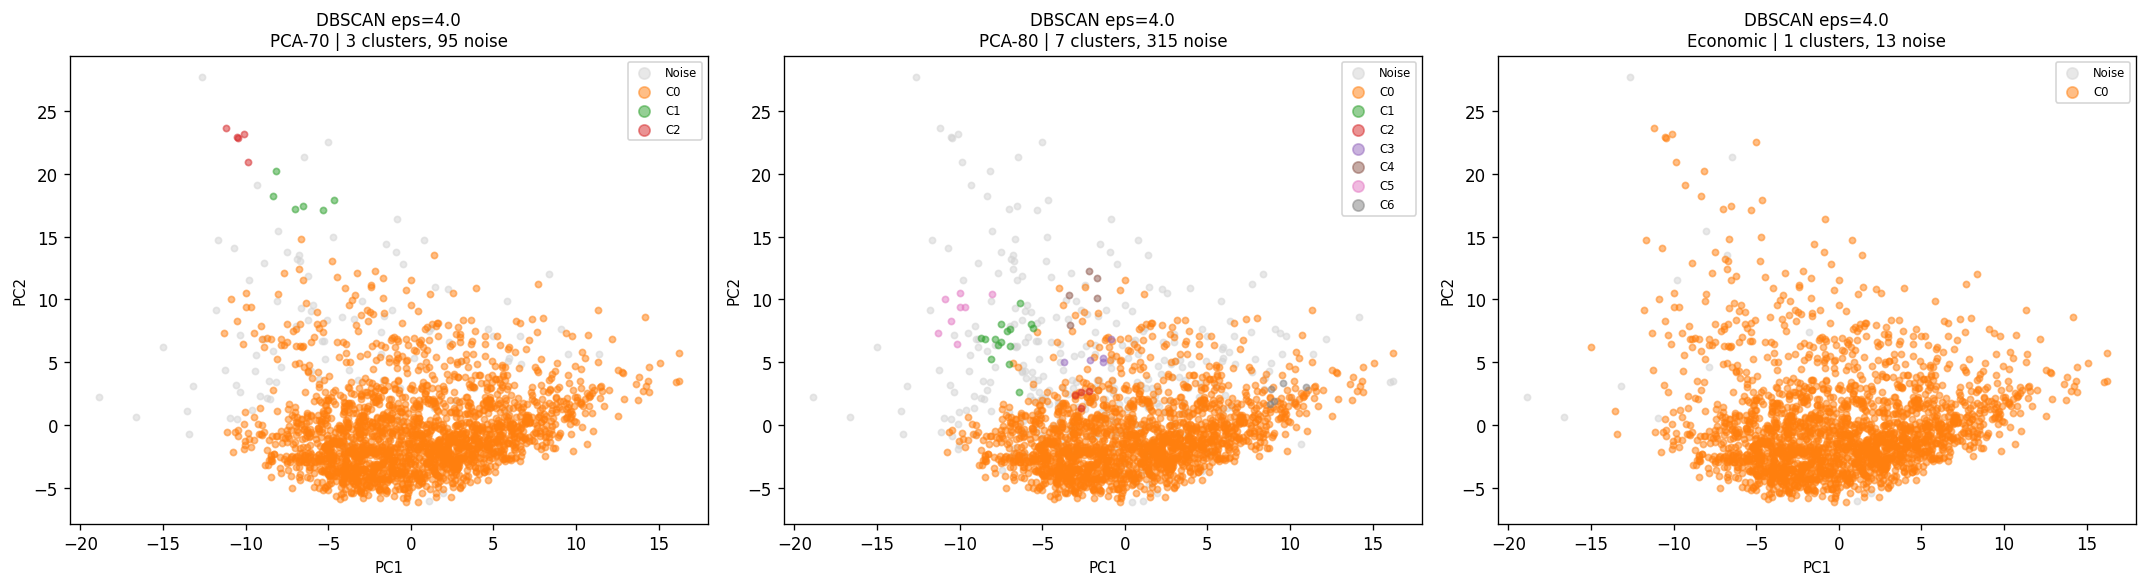

DBSCAN results saved.


In [10]:
dbscan_fs = {'PCA-70': X_pca70.values, 'PCA-80': X_pca80.values, 'Economic': X_econ.values}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, X) in enumerate(dbscan_fs.items()):
    db = DBSCAN(eps=best_cfg['eps'], min_samples=best_cfg['min_samples'])
    labels = db.fit_predict(X)
    m = compute_metrics(X, labels)
    dbscan_results[f'best_{name}'] = {'labels': labels, 'metrics': m}
    plot_clusters(X_viz, labels,
                  f'DBSCAN eps={best_cfg["eps"]}\n{name} | {m["n_clusters"]} clusters, {m["n_noise"]} noise',
                  axes[i])
    print(f'  {name:<10} clusters={m["n_clusters"]}, noise={m["n_noise"]}, sil={m["silhouette"]:.4f}')

plt.tight_layout()
plt.savefig('../figures/dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['DBSCAN'] = dbscan_results
joblib.dump(dbscan_results, '../results/results_dbscan.pkl')
print('DBSCAN results saved.')

---
## Algoritam 4 — CLARANS

Klasterovanje velikih skupova podataka zasnovano na nasumičnoj pretrazi. Predstavlja generalizaciju k-medoid algoritma.   
Ključni parametri:
- `numlocal` — koliko puta se ponavlja ceo postupak pronalaženja lokalnog optimuma
- `maxneighbor` — maksimalan broj suseda koji se ispituje po iteraciji

S obzirom da je algoritam složenosti O(n²), CLARANS se izvršava na skupovima sa smanjenom dimenzionalnošću (PCA-70, PCA-80, Economic).
> **Napomena:** Radi efikasnosti, pokrenuo sam CLARANS na nasumičnom uzorku od 300 instanci, s obzirom da algoritam radi ekstremno sporo za svih 2215 instanci. Dobijeni rezultat je i dalje reprezentativan (detaljnije objašnjenje nalazi se u PDF dokumentu).

Running CLARANS (k=3, numlocal=2, maxneighbor=5, sample=300)...
  CLARANS (PCA-70)... sil=0.2088  DB=1.7118  CH=476.6
  CLARANS (PCA-80)... sil=0.1851  DB=1.5895  CH=346.7
  CLARANS (Economic)... sil=0.2153  DB=1.6814  CH=611.0


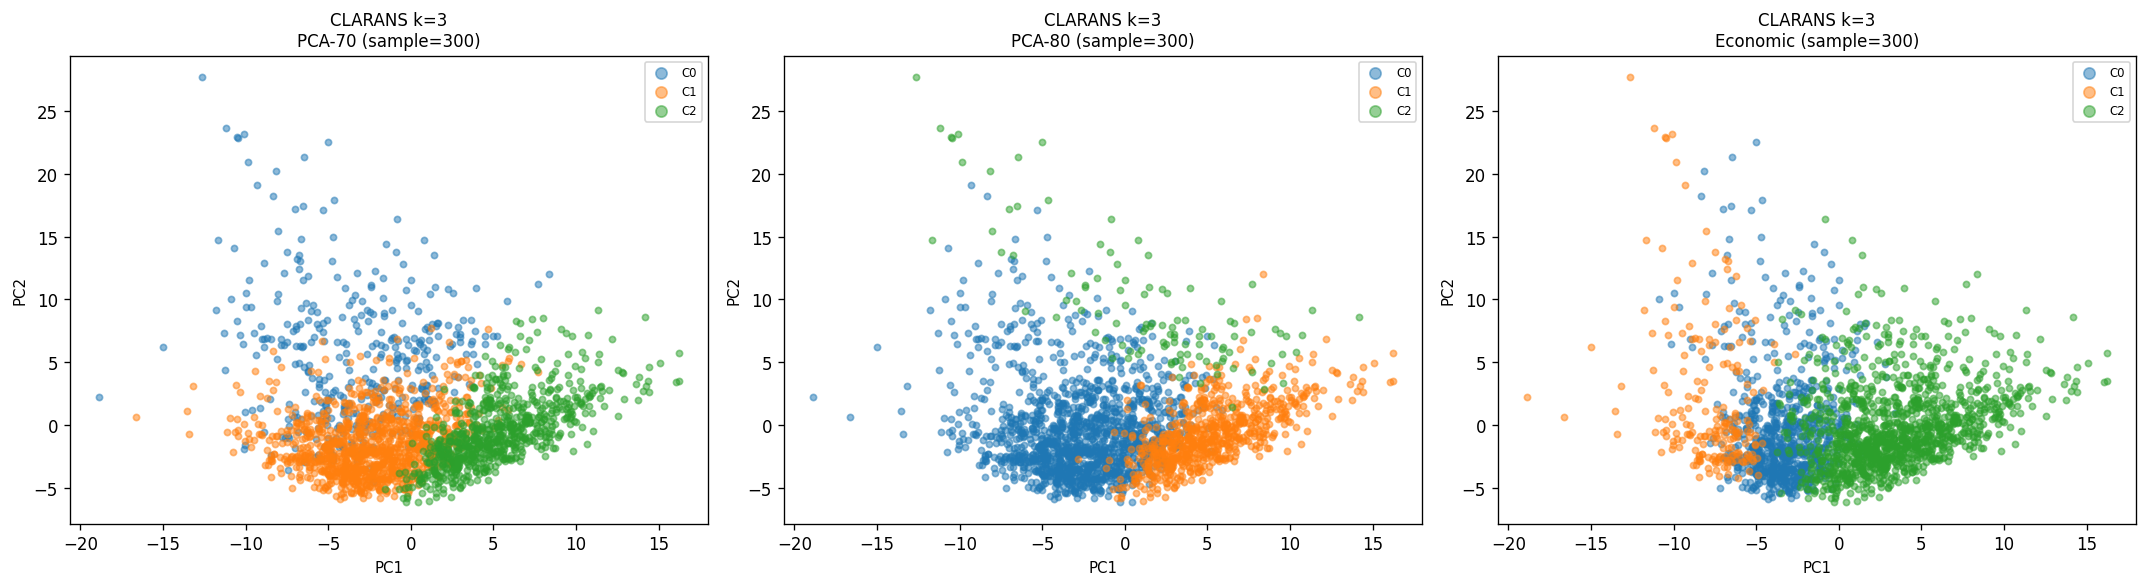

CLARANS saved.


In [11]:
clarans_fs = {'PCA-70': X_pca70.values, 'PCA-80': X_pca80.values, 'Economic': X_econ.values}
clarans_results = {}

NUMLOCAL    = 2
MAXNEIGHBOR = 5
SAMPLE_SIZE = 300

print(f'Running CLARANS (k={best_k}, numlocal={NUMLOCAL}, maxneighbor={MAXNEIGHBOR}, sample={SAMPLE_SIZE})...')

np.random.seed(42)
sample_idx = np.random.choice(len(X_full), size=SAMPLE_SIZE, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, X) in enumerate(clarans_fs.items()):
    print(f'  CLARANS ({name})...', end=' ', flush=True)
    X_sample = X[sample_idx]

    cl = CLARANS_algo(X_sample.tolist(), best_k, NUMLOCAL, MAXNEIGHBOR)
    cl.process()

    medoid_indices = cl.get_medoids()
    medoids = X_sample[medoid_indices]

    from sklearn.metrics import pairwise_distances
    dists = pairwise_distances(X, medoids)
    labels = np.argmin(dists, axis=1)

    m = compute_metrics(X, labels)
    clarans_results[name] = {'labels': labels, 'metrics': m}
    plot_clusters(X_viz, labels, f'CLARANS k={best_k}\n{name} (sample={SAMPLE_SIZE})', axes[i])
    print(f'sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  CH={m["calinski_harabasz"]:.1f}')

plt.tight_layout()
plt.savefig('../figures/clarans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['CLARANS'] = clarans_results
joblib.dump(clarans_results, '../results/results_clarans.pkl')
print('CLARANS saved.')

---
## Algoritam 5 — BIRCH
Kombinacija hijerarhijskog klasterovanja tipa odozgo nadole i algoritma k-sredina.

Running BIRCH (n_clusters=3) on all feature sets...
  Full         sil=0.1604  DB=1.8891  CH=324.6
  PCA-70       sil=0.2429  DB=1.4122  CH=540.3
  PCA-80       sil=0.1965  DB=1.6076  CH=423.9
  Economic     sil=0.1559  DB=1.6410  CH=614.5


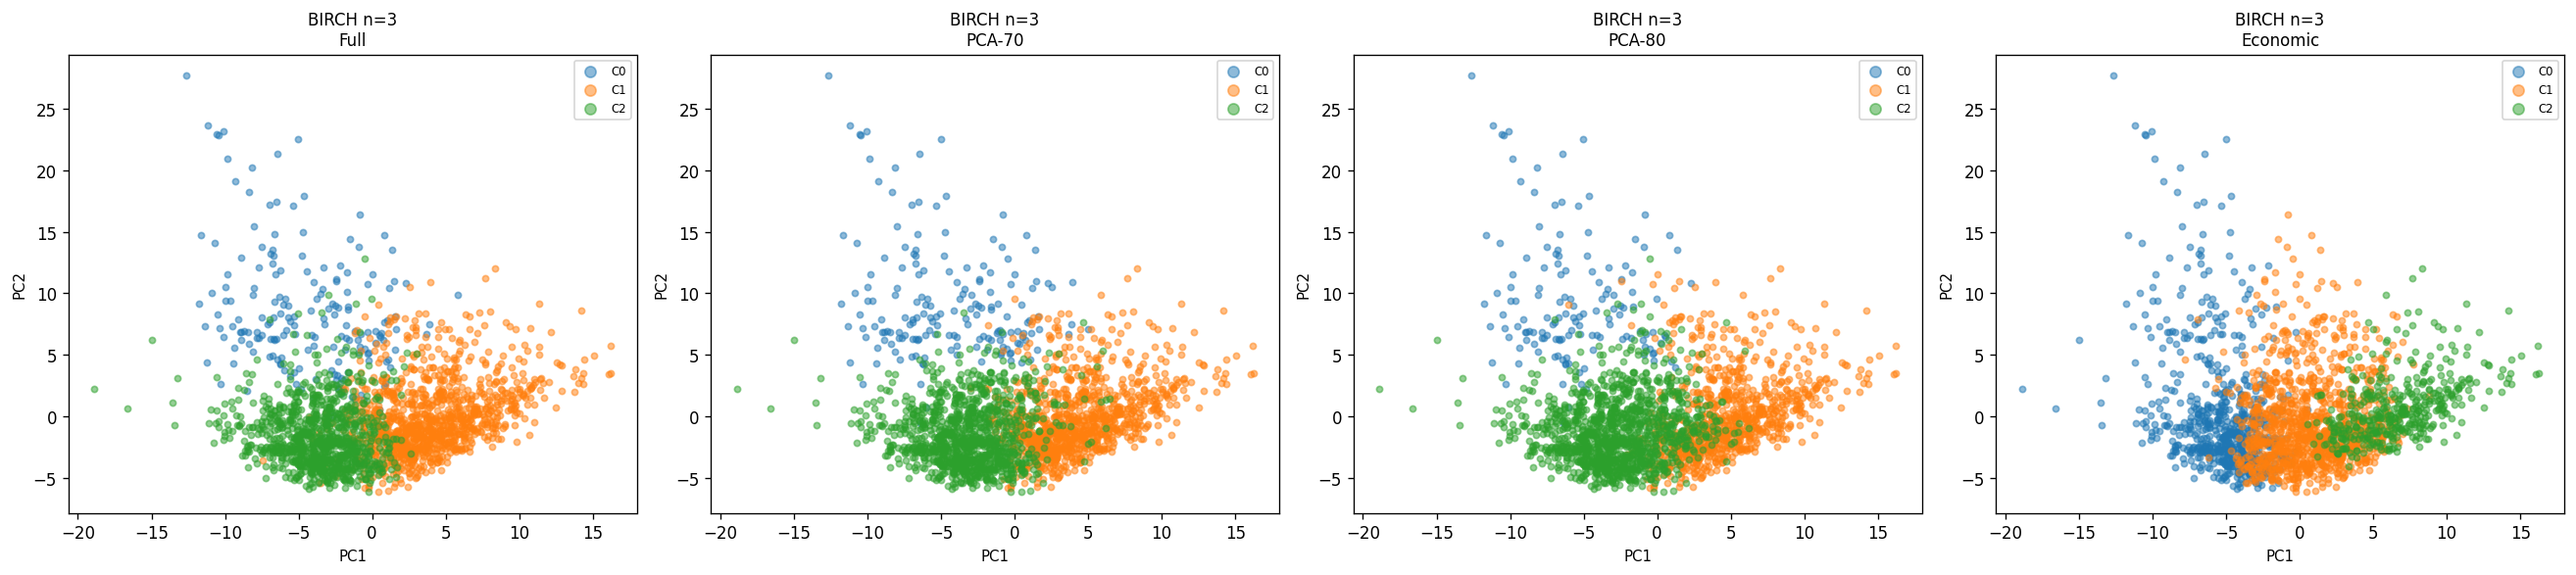

BIRCH saved.


In [12]:
print(f'Running BIRCH (n_clusters={best_k}) on all feature sets...')
birch_results = {}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (name, X) in enumerate(feature_sets.items()):
    birch = Birch(n_clusters=best_k, threshold=0.5)
    labels = birch.fit_predict(X)
    m = compute_metrics(X, labels)
    birch_results[name] = {'labels': labels, 'metrics': m, 'model': birch}
    plot_clusters(X_viz, labels, f'BIRCH n={best_k}\n{name}', axes[i])
    print(f'  {name:<12} sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  CH={m["calinski_harabasz"]:.1f}')

plt.tight_layout()
plt.savefig('../figures/birch_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['BIRCH'] = birch_results
joblib.dump(birch_results, '../results/results_birch.pkl')
print('BIRCH saved.')

---
## Algoritam 6 — CURE

Klasterovanje pomoću reprezentativnih tačaka.  
Svaki klaster je predstavljen sa više **reprezentativnih tačaka** koje se zatim skupljaju ka centru klastera u skladu sa određenim faktorom kompresije.  
Glavna prednost ovog algoritma ogleda se u robusnosti na nesferične oblike klastera i autlajere.

Ključni parametri:
- `number_represent_points` — broj reprezentativnih tačaka po klasteru
- `compression` — faktor (intenzitet) skupljanja ka centroidu

CURE se izvršava na skupovima sa smanjenom dimenzionalnošću (PCA-70, PCA-80, Economic).

Running CURE (k=3, n_repr=5, compression=0.5)...
  CURE (PCA-70)... sil=0.6561  DB=0.4540  CH=110.1
  CURE (PCA-80)... sil=0.7504  DB=0.2869  CH=93.0
  CURE (Economic)... sil=0.6796  DB=0.3130  CH=47.9


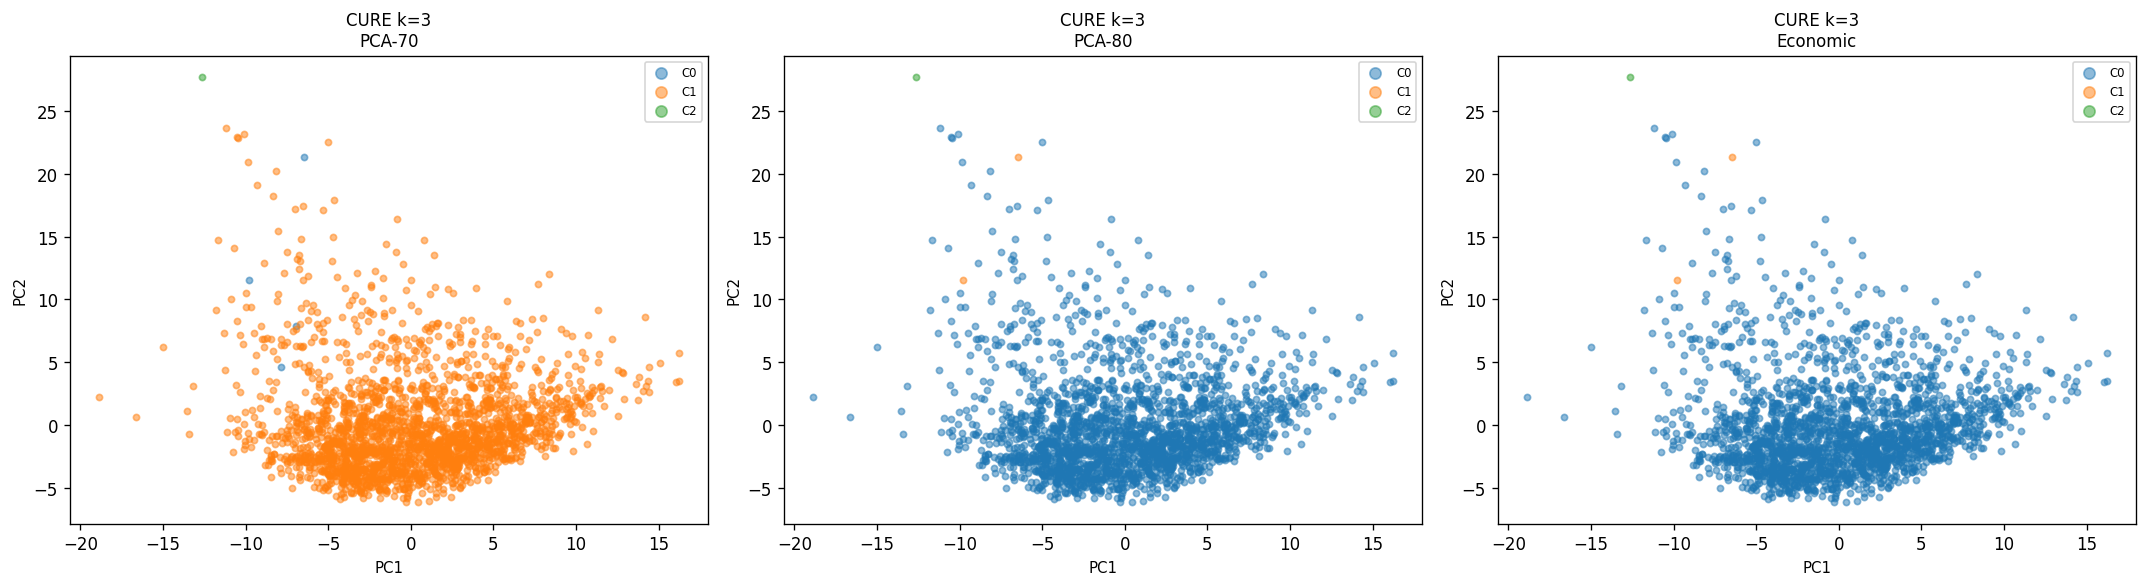


CURE and all results saved.


In [14]:
cure_fs = {'PCA-70': X_pca70.values, 'PCA-80': X_pca80.values, 'Economic': X_econ.values}
cure_results = {}

N_REPR      = 5
COMPRESSION = 0.5

print(f'Running CURE (k={best_k}, n_repr={N_REPR}, compression={COMPRESSION})...')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, X) in enumerate(cure_fs.items()):
    print(f'  CURE ({name})...', end=' ', flush=True)
    cu = CURE_algo(X.tolist(), best_k, N_REPR, COMPRESSION)
    cu.process()
    labels = pyclustering_to_labels(cu.get_clusters(), len(X))
    m = compute_metrics(X, labels)
    cure_results[name] = {'labels': labels, 'metrics': m}
    plot_clusters(X_viz, labels, f'CURE k={best_k}\n{name}', axes[i])
    print(f'sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.4f}  CH={m["calinski_harabasz"]:.1f}')

plt.tight_layout()
plt.savefig('../figures/cure_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['CURE'] = cure_results
joblib.dump(cure_results, '../results/results_cure.pkl')
joblib.dump(all_results, '../results/all_results.pkl')
print('\nCURE and all results saved.')

---
## Pregled metrika

In [22]:
rows = []

for name, res in all_results['KMeans'].items():
    m = res['metrics']
    rows.append({'Algorithm': 'K-Means', 'Feature Set': name,
                 'n_clusters': m['n_clusters'],
                 'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                 'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                 'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

for key, res in all_results['Agglomerative'].items():
    if key.startswith('ward_'):
        name = key.replace('ward_', '')
        m = res['metrics']
        rows.append({'Algorithm': 'Agglomerative (Ward)', 'Feature Set': name,
                     'n_clusters': m['n_clusters'],
                     'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                     'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                     'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

for key in ['best_PCA-70', 'best_PCA-80', 'best_Economic']:
    if key in all_results['DBSCAN']:
        m = all_results['DBSCAN'][key]['metrics']
        rows.append({'Algorithm': 'DBSCAN', 'Feature Set': key.replace('best_', ''),
                     'n_clusters': m['n_clusters'],
                     'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                     'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                     'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

for name, res in all_results['CLARANS'].items():
    m = res['metrics']
    rows.append({'Algorithm': 'CLARANS', 'Feature Set': name,
                 'n_clusters': m['n_clusters'],
                 'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                 'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                 'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

for name, res in all_results['BIRCH'].items():
    m = res['metrics']
    rows.append({'Algorithm': 'BIRCH', 'Feature Set': name,
                 'n_clusters': m['n_clusters'],
                 'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                 'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                 'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

for name, res in all_results['CURE'].items():
    m = res['metrics']
    rows.append({'Algorithm': 'CURE', 'Feature Set': name,
                 'n_clusters': m['n_clusters'],
                 'Silhouette': round(m['silhouette'], 4) if not np.isnan(m['silhouette']) else None,
                 'Davies-Bouldin': round(m['davies_bouldin'], 4) if not np.isnan(m['davies_bouldin']) else None,
                 'Calinski-Harabasz': round(m['calinski_harabasz'], 1) if not np.isnan(m['calinski_harabasz']) else None})

results_df = pd.DataFrame(rows)
results_df.to_csv('../results/clustering_results.csv', index=False)
print('Results saved to clustering_results.csv')
df_display = results_df.sort_values('Silhouette', ascending=False).head(20).reset_index(drop=True)
df_display.index += 1
df_display

Results saved to clustering_results.csv


,Algorithm,Feature Set,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
1,CURE,PCA-80,3,0.7504,0.2869,93.0
2,CURE,Economic,3,0.6796,0.3130,47.9
3,CURE,PCA-70,3,0.6561,0.4540,110.1
4,DBSCAN,PCA-70,3,0.5612,0.6230,62.3
5,K-Means,PCA-70,3,0.2686,1.3279,606.3
6,BIRCH,PCA-70,3,0.2429,1.4122,540.3
7,Agglomerative (Ward),PCA-70,3,0.2325,1.4068,504.6
8,K-Means,PCA-80,3,0.2277,1.5045,502.4
9,CLARANS,Economic,3,0.2153,1.6814,611.0
10,Agglomerative (Ward),Economic,3,0.2118,1.6467,608.0
